**Universidad Internacional de La Rioja (UNIR) - Máster Universitario en Inteligencia Artificial - Procesamiento del Lenguaje Natural** 

***
Datos del alumno (Nombre y Apellidos): José

Fecha: 05/12/2025
***

<span style="font-size: 20pt; font-weight: bold; color: #0098cd;">Trabajo: Caracterización de textos</span>

**Objetivos** 

Con esta actividad se tratará de que el alumno se familiarice con el manejo de la librería spacy, así como con los conceptos básicos de manejo de las técnicas NER

**Descripción**

En esta actividad debes procesar de forma automática un texto en lenguaje natural para detectar características básicas en el mismo, y para identificar y etiquetar las ocurrencias de conceptos como localización, moneda, empresas, etc.

En la primera parte del ejercicio se proporciona un código fuente a través del cual se lee un archivo de texto y se realiza un preprocesado del mismo. En esta parte el alumno tan sólo debe ejecutar y entender el código proporcionado.

En la segunda parte del ejercicio se plantean una serie de preguntas que deben ser respondidas por el alumno. Cada pregunta deberá responderse con un fragmento de código fuente que esté acompañado de la explicación correspondiente. Para elaborar el código solicitado, el alumno deberá visitar la documentación de la librería spacy, cuyos enlaces se proporcionarán donde corresponda.

# Parte 1: carga y preprocesamiento del texto a analizar

Observa las diferentes librerías que se están importando.

In [1]:
import pathlib
import spacy
import pandas as pd
from spacy import displacy
import csv
import es_core_news_md

El siguiente código simplemente carga y preprocesa el texto. Para ello, lo primero que hace es cargar un modelo de lenguaje previamente entrenado. En este caso, se utiliza <i>es_core_news_md</i>: 

https://spacy.io/models/es#es_core_news_md


In [2]:
nlp = es_core_news_md.load()

El objeto <i>nlp</i> permite utilizar el modelo de lenguaje cargado, de forma que se puede procesar un texto y obtenerlo en su versión preprocesada. Así, nos permite realizar las diferentes tareas. En este caso, vamos a utilizar el pipeline para hacer un preprocesamiento básico, que consiste en tokenizar el texto.

<ul style="color: green">Se parte del fichero de comentarios despues de ejecutar el algoritmo entregado por el profesor en el foro de la actividad.</ul>
<ul style="color: green">Tambien se ponen comentarios en el código despues de la mara "######## JG" para diferenciar sobre los comentarios de la actividad.</ul>

In [3]:
# filename = "./02Dataset_sin_procesar.csv"
filename = "/Users/josejp/Documents/2025/2_UNIR/Semenstre_1/Procesamiento_Lenguaje_Natural/Actividad_1/comentarios_limpio_utf8.csv"
lines_number = 10000
######## JG
# Se lee el dataset con algunos parametros para aligerar y controlar la carga.
# Se utilizan solo las columnas necesarias y se especifica el tipo de dato
# Se establece la decodificación más simple por encontrar un error al utilizar utf-8 por caracteres extraños. Evito problemas de lectura hasta más adelante en caso se necesite resolver.
# Despues que el profesor entregara un algoritmo capas de resolver alguno problemas de codificación, procedo a cambiar el encoding a 'utf-8'
######## JG
data = pd.read_csv(filename, sep=';', nrows=lines_number, usecols=['CONTENIDO A ANALIZAR', 'INTENSIDAD'], dtype={'CONTENIDO A ANALIZAR': 'str', 'INTENSIDAD': 'int32'}, encoding='utf-8')

El código anterior carga el archivo CSV (opcionalmente con un límite de líneas a leer) y genera la variable <i>data</i>, que contiene un Dataframe (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) con los datos leídos del CSV.

Te vendrá bien conocer la siguiente documentación:
<ul>
    <li>https://spacy.io/api/doc</li>
    <li>https://spacy.io/api/token</li>
    <li>https://spacy.io/api/morphology#morphanalysis</li>
</ul>

### Playground

Utiliza este espacio para hacer pruebas y ensayos con las variables generadas con el código previo. A modo de ejemplo, se ofrece código que realiza las siguientes tareas: 


- leer un número dado de líneas del Dataframe y generar dos listas con los valores (se pueden leer directamente del DataFrame, se muestra el ejemplo como una opción más)
- procesar el texto de cada comentario


Para procesarlo, hay utilizar el objeto <i>nlp</i> y así obtener objetos de la clase <i>Doc</i> (https://spacy.io/api/doc)

Visita la documentación de dicha clase y experimenta probando las diferentes funciones y atributos 

In [4]:
# Puedes insertar aquí código de pruebas para experimentar con las diferentes funciones y atributos de 'doc'.
doc = []
value = []

#con el bucle, generamos sendas listas con los comentarios ya parseados y con el valor de intensidad
for i in range(0, 2):
    
    #en un primer paso se parsea el comentario. En el segundo paso se añade el objeto a la lista
    tmp_doc = nlp(data["CONTENIDO A ANALIZAR"][i])
    doc.append(tmp_doc)
    
    #en un primer paso extrae el valor. En el segundo paso se añade el valor a la lista
    tmp_value = data["INTENSIDAD"][i]
    value.append(tmp_value)

print(f'Valores de CONTENIDO: {doc}')
print(f'Valores de INTENSIDAD: {value}')

#ejemplo de cómo recorrer un comentario palabra por palabra
i = 0
for token in doc[1]:
    if i == 5:
        break
    print(token)
    i += 1
    
######## JG
# Ejemplo de Morfologia -> FEATS 
i = 0
for token in doc[1]:
    if i == 5:
        break
    print(f'Token: {token.text}, Feats: {token.morph}')
    i += 1

# Diferencia en la lectura de cadenas. En el ejemplo anterior hace el split por palabras y aqui por letra.
for token in "TEXTO DE PRUEBA":
    print(token)
######## JG

Valores de CONTENIDO: [el barï½ï½a nunca acaeza ante un segundo b ni ante un tercera , ya estan los arbitros para impedirlo....lo de messi es una autentica vergï½ï½enza, el real madrid ha puesto punto y final a su andadura en la copa del rey en el primer escalï½n. los de zidane han caï½ï½do ante el alcoyano, de segunda b, a pesar de empezar ganando y jugar con un hombre menos en la prï½rroga. el tï½cnico francï½s dispuso un equipo plagado de los menos habituales, con vinicius y mariano en ataque. ninguno de los dos logrï½ crear ocasiones. fue militao el que marcï½ el gol del madrid, justo antes del descanso. en la segunda parte intentaron cerrar el partido, pero sin el colmillo suficiente y el modesto alcoyano aprovechï½ un cï½rner para empatar el partido a cinco minutos para el final. el empate sentï½ como un jarro de agua frï½ï½a a los blancos, que lo intentaron en el tiempo extra a falta de cinco minutos, el casanova consiguiï½ el gol mï½s importante de su vida, que vale la clasific

In [5]:
######## JG Vistazo rapido para saber que no existen valores nulos. Count excluye los valores nulos
data.describe(include='object')

,CONTENIDO A ANALIZAR
count,10000
unique,9887
top,[USUARIO_OFUSCADO]
freq,22


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 1.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuántos registros contiene el corpus?</span>

In [6]:
# Incluye aquí el código generado para poder responder a tu pregunta

print(f'Numero de registros en el dataframe (corpus) cargado: {len(data)}')

Numero de registros en el dataframe (corpus) cargado: 10000


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>
 

<p>Esta respuesta se podria responder sin ejecutar código, ya que tenemos una variable donde limitamos el tamaño del corpus, por ejemplo a 10000 registros. Sin embargo, se ejecuta el código anterior para realizar una verificación adicional.</p>
<p>Tener en cuenta que la cabecera no se considera como dato. Es decir, se cargan 10000 filas de datos más 1 fila de cabecera, dando un total de 10001 filas leídas del archivo.</p>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 2.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuántas palabras totales hay en los comentarios del corpus?</span>

In [7]:
######## JG Prueba para diferenciar palabras, símbolos y espacios
doc = nlp("ESTO, ES UNA PRUEBA.     ¡ESTO TAMBIEN!")
for token in doc:
    print(token)
    print(token.pos_)
######## JG

ESTO
PROPN
,
PUNCT
ES
AUX
UNA
DET
PRUEBA
NOUN
.
PUNCT
    
SPACE
¡
PUNCT
ESTO
NOUN
TAMBIEN
ADJ
!
PUNCT


In [8]:
# Incluye aquí el código generado para poder responder a tu pregunta
counter = 0
for _, row in data.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	for token in doc:
		if token.pos_ not in ['PUNCT', 'SPACE']:
			counter += 1
print(f'Numero total de palabras en los comentarios del corpus: {counter}')

Numero total de palabras en los comentarios del corpus: 219078


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>
 

<p>Utilizo la libreria de spiCy para procesar los comentarios y así tener una forma rapida de poder leer palabras y no tener que construir un algoritmo propio. Tambien utilizo la función <code>pos_</code> para diferenciar signos y espacios entre los tokens.</p>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 3.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuál el número promedio de palabras en cada comentario?</span>

In [9]:
# Incluye aquí el código generado para poder responder a tu pregunta
print(f'Sumatoria de palabras por comentario: {counter}')
print(f'Total de comentarios: {len(data)}')
print(f'Promedio de palabras por comentario: {counter / len(data)}')

Sumatoria de palabras por comentario: 219078
Total de comentarios: 10000
Promedio de palabras por comentario: 21.9078


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>
 

<p>Tenemos en cuenta que el promedio lo calculamos como: Sumatoria de palabras por comentario / El total de comentarios</p>
<p>Dado que las variables del cálculo son conocidas, aplico directamente el operación.</p>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 4.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál el número promedio de palabras en los comentarios de cada grupo?</span>

In [10]:
# Incluye aquí el código generado para poder responder a tu pregunta

######## JG Comento esta linea porque ya estoy leyendo la columna como numérica. Cosa que antes no hice por no necesitarlo.
# data['INTENSIDAD'] = pd.to_numeric(data['INTENSIDAD'])

hate_word = 0
no_hate_word = 0

hate_rows = data[data['INTENSIDAD']>0].shape[0]
no_hate_rows = data[data['INTENSIDAD']==0].shape[0]

for _, row in data.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	if row['INTENSIDAD'] > 0:
		for token in doc:
			if token.pos_ not in ['PUNCT', 'SPACE']:
				hate_word += 1
	else:
		for token in doc:
			if token.pos_ not in ['PUNCT', 'SPACE']:
				no_hate_word += 1

print(f'Numero total de palabras en comentarios con odio: {hate_word}')
print(f'Numero total de comentarios con odio: {hate_rows}')
print(f'Promedio de palabras por comentario con odio: {round(hate_word / hate_rows,2)}')

print(f'Numero total de palabras en comentarios sin odio: {no_hate_word}')
print(f'Numero total de comentarios sin odio: {no_hate_rows}')
print(f'Promedio de palabras por comentario sin odio: {round(no_hate_word / no_hate_rows,2)}')

Numero total de palabras en comentarios con odio: 17258
Numero total de comentarios con odio: 748
Promedio de palabras por comentario con odio: 23.07
Numero total de palabras en comentarios sin odio: 201820
Numero total de comentarios sin odio: 9252
Promedio de palabras por comentario sin odio: 21.81


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>
 

<p>Premisas</p>
<ul>
  <li>Si INTENSIDAD == 0 → el mensaje no contiene odio.</li>
  <li>Si INTENSIDAD > 0 → el mensaje sí contiene odio.</li>
</ul>

<p>Interpretación del resultado</p>
<ul>
  <li>El corpus está desbalanceado, dado que los comentarios con odio (748) representan menos del 10% del total (10000).</li>
  <li>El número de palabras por comentario no es un buen indicador para identificar si un comentario contiene odio, ya que el promedio es similar entre ambas clases (con odio 23 y sin odio 21).</li>
</ul>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 5.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el número promedio de oraciones en los comentarios de cada grupo?</span>

In [11]:
# Incluye aquí el código generado para poder responder a tu pregunta

df_hate = data[data['INTENSIDAD'] > 0]
span_hate_count = 0
for _, row in df_hate.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	span_hate_count += len(list(doc.sents))
print(f'Numero total de comentarios con odio: {len(df_hate)}')
print(f'Numero total de oraciones en comentarios con odio: {span_hate_count}')
print(f'Promedio de oraciones por comentario con odio: {round(span_hate_count / len(df_hate),2)}')

df_no_hate = data[data['INTENSIDAD'] == 0]
span_nohate_count = 0
for _, row in df_no_hate.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	span_nohate_count += len(list(doc.sents))
print(f'Numero total de comentarios sin odio: {len(df_no_hate)}')
print(f'Numero total de oraciones en comentarios sin odio: {span_nohate_count}')
print(f'Promedio de oraciones por comentario sin odio: {round(span_nohate_count / len(df_no_hate),2)}')

Numero total de comentarios con odio: 748
Numero total de oraciones en comentarios con odio: 1341
Promedio de oraciones por comentario con odio: 1.79
Numero total de comentarios sin odio: 9252
Numero total de oraciones en comentarios sin odio: 16613
Promedio de oraciones por comentario sin odio: 1.8


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>
 


<p>Premisas</p>
<ul>
  <li>Si INTENSIDAD == 0 → el mensaje no contiene odio.</li>
  <li>Si INTENSIDAD > 0 → el mensaje sí contiene odio.</li>
</ul>

<p>El promedio de oraciones por comentario es similar tanto en los mensajes marcados como con odio como en los que no lo están. Esto indica que esta variable no está correlacionada con la presencia de odio en un comentario. Por lo tanto, sería necesario buscar otras variables que puedan contribuir mejor a un propósito predictivo.</p>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 6.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el porcentaje de comentarios que contienen entidades NER en cada grupo?</span>

In [12]:
# Incluye aquí el código generado para poder responder a tu pregunta
ner_counter = 0
for _, row in df_hate.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	ner_counter += len(doc.ents)
print(f'Numero total de comentarios con odio: {len(df_hate)}')
print(f'Numero total de NER en comentarios con odio: {ner_counter}')
print(f'Porcentaje de NER por comentario con odio: {round((ner_counter / len(df_hate))*100,2)}%')

ner_counter = 0
for _, row in df_no_hate.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	ner_counter += len(doc.ents)
print(f'Numero total de comentarios sin odio: {len(df_no_hate)}')
print(f'Numero total de NER en comentarios sin odio: {ner_counter}')
print(f'Porcentaje de NER por comentario sin odio: {round((ner_counter / len(df_no_hate))*100,2)}%')

Numero total de comentarios con odio: 748
Numero total de NER en comentarios con odio: 810
Porcentaje de NER por comentario con odio: 108.29%
Numero total de comentarios sin odio: 9252
Numero total de NER en comentarios sin odio: 9118
Porcentaje de NER por comentario sin odio: 98.55%


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>
 

<p>Premisas</p>
<ul>
  <li>Si INTENSIDAD == 0 → el mensaje no contiene odio.</li>
  <li>Si INTENSIDAD > 0 → el mensaje sí contiene odio.</li>
</ul>

<p>Es importante tener en cuenta que hay palabras que tienen caracteres extraños y son contabilizados como NER pero no lo son, lo mismo ocurre a la inversa.</p>

<p>Los resultados son bastante similares entre ambas clases, por lo que esta variable es poco relevante para ser utilizada para la predicción. Sin embargo, dado que el porcentaje es cercado al 100% se puede deducir que la mayoria de comentarios tiene al menos una entidad NER, lo que indica que que se refieren a elementos especifico, como personas, organzaciones, paises, etc.</p>


<span style="font-size: 16pt; font-weight: bold; color: #0098cd;">Plantea tus propias preguntas</span>

<span><b>Plantea al menos 4 características</b> del texto cuyo análisis permita una caracterización completa del texto. Puedes utilizar recomendaciones proporcionadas por la IA Generativa, si así lo deseas. Para cada una de las características planteadas, obtén valores separados para los grupos ODIO/NO-ODIO.</span>

<span>En la explicación aportada, deberás <b>explicar el significado de la característica planteada</b> así como la importancia de ésta en la caracterización del texto.</span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica adicional 1.</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuales son los adjetivos que más se utilizan en comentarios con y sin odio?</span>

In [13]:
######## JG Prueba para diferenciar adjetivos
# Se identifica que la precisión no es tan buena pero puede servir como aproximación.
doc = nlp("ESTO ES UNA PRUEBA buena.     ¡ESTO TAMBIEN ES UNA PRUEBA TONTA!")
for token in doc:
    if token.pos_ == 'ADJ':
    	print(token, token.pos_)
######## JG

buena ADJ
TAMBIEN ADJ
TONTA ADJ


In [14]:
# Incluye aquí el código generado para poder responder a tu pregunta

words = []
for _, row in df_hate.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	for token in doc:
		if token.pos_ == 'ADJ':
			words.append(token.lemma_.lower().strip())

word_count = {}
for word in words:
	if word in word_count:
		word_count[word] += 1
	else:
		word_count[word] = 1

adj_hate_words = sorted(word_count.items(), key=lambda x: x[1], reverse=True)

print('Los 5 adjetivos más comunes en comentarios con odio son:')
for word, count in adj_hate_words[:5]:
    print(f'Palabra: {word}, Contador: {count}')


words = []
for _, row in df_no_hate.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	for token in doc:
		if token.pos_ == 'ADJ':
			words.append(token.lemma_.lower().strip())

word_count = {}
for word in words:
	if word in word_count:
		word_count[word] += 1
	else:
		word_count[word] = 1

sorted_words = sorted(word_count.items(), key=lambda x: x[1], reverse=True)

print('\nLos 5 adjetivos más comunes en comentarios sin odio son:')
for word, count in sorted_words[:5]:
    print(f'Palabra: {word}, Contador: {count}')

Los 5 adjetivos más comunes en comentarios con odio son:
Palabra: polï½ï½tico, Contador: 16
Palabra: mejor, Contador: 13
Palabra: periï½dico, Contador: 13
Palabra: menudo, Contador: 13
Palabra: tonto, Contador: 13

Los 5 adjetivos más comunes en comentarios sin odio son:
Palabra: primero, Contador: 173
Palabra: mejor, Contador: 168
Palabra: gran, Contador: 128
Palabra: estï½n, Contador: 124
Palabra: nuevo, Contador: 123


<b>Incluye aquí, debajo de la línea, la explicación de la característica propuesta y su motivación. Incluye también una explicación del código fuente aportado.</b>
<hr>
 

<p>Explicación del código</p>
<ul>
<li>1. Se recorre el dataframe que contiene los comentarios con odio.</li>
<li>2. Cada comentario se procesa con la librería spaCy para obtener un objeto de tipoc doc.</li>
<li>3. Se verifica si el token es un adjetivo para guardar el lema de la palabra en un diccionario.</li>
<li>4. Se recorre ese diccionario para contabilizar las repeticiones.</li>
<li>5. Si la palabra existe se incrementa su contador, en caso contrario de agrega.</li>
<li>6. Se ordena el diccionario de forma descendente según el número de repeticiones y se seleccionando los 5 adjetivos más frecuentes.</li>
<li>7. Se repetie el mismo procedimiento (pasos 1 a 6) para los comentarios sin odio.</li>
</ul>

<p>Explicación de la característica</p>
<span>Se listan los adjetivos más frecuentes en los comentarios con y sin odio. Esto podria ser util en caso se necesite tener un diccionario de palabras bloquedas que impida publicar ciertos mensajes y así reducir los comentarios con odio. Sin embargo, este enfoque es facilmente vulnerado, ya que los usuarios pueden emplear faltas ortograficas, sustituir letras por números o simbolos o realizar variaciones similares para burlar el diccionario.<span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica adicional 2.</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Qué entidades nombradas (NER) aparecen con mayor frecuencia en los comentarios con odio?</span>

In [15]:
# Incluye aquí el código generado para poder responder a tu pregunta

words = []
for _, row in df_hate.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	for ent in doc.ents:
		words.append(ent.text.lower().strip())

word_count = {}
for word in words:
	if word in word_count:
		word_count[word] += 1
	else:
		word_count[word] = 1

hate_words = sorted(word_count.items(), key=lambda x: x[1], reverse=True)

print('Los 10 NER más comunes en comentarios con odio son:')
for word, count in hate_words[:10]:
    print(f'Palabra: {word}, Contador: {count}')

Los 10 NER más comunes en comentarios con odio son:
Palabra: mï½s, Contador: 19
Palabra: vergï½ï½enza, Contador: 18
Palabra: ï½s, Contador: 18
Palabra: paï½ï½s, Contador: 15
Palabra: puta, Contador: 14
Palabra: gentuza, Contador: 14
Palabra: pp, Contador: 13
Palabra: madrid, Contador: 11
Palabra: ademï½s, Contador: 9
Palabra: perï½ï½, Contador: 8


<b>Incluye aquí, debajo de la línea, la explicación de la característica propuesta y su motivación. Incluye también una explicación del código fuente aportado.</b>
<hr>
 

<p>Explicación del código</p>
<ul>
<li>1. Se recorre el dataframe que contiene los comentarios con odio.</li>
<li>2. Cada comentario se procesa con la librería spaCy para obtener un objeto de tipoc doc.</li>
<li>3. Se verifica si el comentario tiene entidades NER.</li>
<li>4. Se recorre las entidades NER para convertir a texto y guardar en un diccionario.</li>
<li>5. Si la palabra existe en el diccionario se incrementa su contador, en caso contrario de agrega.</li>
<li>6. Se ordena el diccionario de forma descendente según el número de repeticiones y se seleccionando las 5 entidades NER más frecuentes.</li>
</ul>

<p>Explicación de la característica</p>

<span>Con este listado de entidades más frecuentes puede servir como una forma de medir cuales son los temas que más se repiten en los comentarios con odio, permitiendo tomar acción para cambiar el enfoque o evitar ciertos topicos.</span>
<p>Aunque algunas entidades no se reconocen completamente debido a caracteres extraños o ruido en los textos, existen otras que sí se identifican correctamente. Un proceso de limpieza más profundo podría mejorar significativamente la calidad de los resultados.</p>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica adicional 3.</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Qué verbos son más frecuentes en comentarios con odio comparados con comentarios sin odio?</span>

In [16]:
doc = nlp("Maria esta estudiando")
for token in doc:
    print(token.pos_)

PROPN
DET
VERB


In [17]:
# Incluye aquí el código generado para poder responder a tu pregunta

words = []
for _, row in df_hate.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	for token in doc:
		if token.pos_ == 'VERB':
			words.append(token.lemma_.lower().strip())

word_count = {}
for word in words:
	if word in word_count:
		word_count[word] += 1
	else:
		word_count[word] = 1

sorted_words = sorted(word_count.items(), key=lambda x: x[1], reverse=True)

print('Los 5 verbos más comunes en comentarios con odio son:')
for word, count in sorted_words[:5]:
    print(f'Palabra: {word}, Contador: {count}')


words = []
for _, row in df_no_hate.iterrows():
	doc = nlp(row['CONTENIDO A ANALIZAR'])
	for token in doc:
		if token.pos_ == 'VERB':
			words.append(token.lemma_.lower().strip())

word_count = {}
for word in words:
	if word in word_count:
		word_count[word] += 1
	else:
		word_count[word] = 1

sorted_words = sorted(word_count.items(), key=lambda x: x[1], reverse=True)

print('\nLos 5 verbos más comunes en comentarios con odio son:')
for word, count in sorted_words[:5]:
    print(f'Palabra: {word}, Contador: {count}')

Los 5 verbos más comunes en comentarios con odio son:
Palabra: tener, Contador: 94
Palabra: hacer, Contador: 66
Palabra: decir, Contador: 45
Palabra: dar, Contador: 44
Palabra: ver, Contador: 38

Los 5 verbos más comunes en comentarios con odio son:
Palabra: tener, Contador: 1052
Palabra: hacer, Contador: 979
Palabra: decir, Contador: 551
Palabra: dar, Contador: 490
Palabra: ver, Contador: 480


<b>Incluye aquí, debajo de la línea, la explicación de la característica propuesta y su motivación. Incluye también una explicación del código fuente aportado.</b>
<hr>
 

<p>Explicación del código</p>
<ul>
<li>1. Se recorre el dataframe que contiene los comentarios con odio.</li>
<li>2. Cada comentario se procesa con la librería spaCy para obtener un objeto de tipoc doc.</li>
<li>3. Se verifica si el token es un verbo para guardar el lema de la palabra en un diccionario.</li>
<li>4. Se recorre ese diccionario para contabilizar las repeticiones.</li>
<li>5. Si la palabra existe se incrementa su contador, en caso contrario de agrega.</li>
<li>6. Se ordena el diccionario de forma descendente según el número de repeticiones y se seleccionando los 5 verbos más frecuentes.</li>
<li>7. Se repetie el mismo procedimiento (pasos 1 a 6) para los comentarios sin odio.</li>
</ul>

<p>Explicación de la característica</p>

<span>La idea de contabilizar los verbos más repetidos en los comentarios con y sin odio era poder construir un diccionario que permita volver a identificar posibles errores de categoriación. Sin embargo, los verbos más frecuentes son los mismos, lo que descarta la utilidad de este indicador para diferenciar entre las dos clases.</span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica adicional 4.</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuál es la longitud de caracteres por comentario en cada grupo (odio vs. no odio)?</span>

In [18]:
data.loc[data['INTENSIDAD'] > 0, 'ODIO'] = 'SI'
data.loc[data['INTENSIDAD'] == 0, 'ODIO'] = 'NO'
data["LEN_CHAR"] = data["CONTENIDO A ANALIZAR"].str.len()
stats = data.groupby("ODIO")["LEN_CHAR"].describe()
print(f'Promedio de caracteres por comentario sin odio: {round(stats["mean"]["NO"],2)}')
print(f'Promedio de caracteres por comentario con odio: {round(stats["mean"]["SI"],2)}')



Promedio de caracteres por comentario sin odio: 130.84
Promedio de caracteres por comentario con odio: 142.08


<p>Explicación del código</p>
<ul>
  <li>1. Se crea una nueva columna <code>ODIO</code> en el dataframe para identificar de forma más directa si el comentario contiene odio.</li>
  <li>2. Se calcula la longitud en caracteres de cada comentario y se guarda en la columna <code>LEN_CHAR</code>.</li>
  <li>3. Se agrupa el dataframe por la columna <code>ODIO</code> y se obtiene la descripción estadística mediante la función <code>describe</code> de pandas.</li>
  <li>4. Se muestra el promedio de caracteres para los comentarios con odio y sin odio.</li>
</ul>

<p>Explicación de la característica</p>

<p>
  El objetivo de esta medida es evaluar si la cantidad de caracteres por comentario puede ayudar a identificar mensajes con odio. La hipótesis era que los comentarios con odio podrían ser más breves, impulsivos o menos elaborados que aquellos sin odio.
</p>

<p>
  Sin embargo, los promedios son muy similares: aproximadamente 130 caracteres en comentarios sin odio y 142 en comentarios con odio. Esto indica que ambos tipos de comentarios presentan comportamientos parecidos en cuanto a longitud.
</p>

<p>
  Por lo tanto, esta variable no resulta representativa para este corpus, ya que la longitud del comentario no diferencia de manera clara entre mensajes con y sin odio.
</p>


<b>Incluye aquí, debajo de la línea, la explicación de la característica propuesta y su motivación. Incluye también una explicación del código fuente aportado.</b>
<hr>
 

<p>Explicación del código</p>
<ul>
<li>1. Se crea una nueva columna "ODIO" en el dataframe para identificar de forma más directa si el comentario tiene odio.</li>
<li>2. Se cuenta la longitud de caracteres de cada comentario y se guarda en la columna "LEN_CHAR".</li>
<li>3. Se agrupa el dataframe por la columna "ODIO" y se obtiene la descripción estadistica mediante la función describe de pandas.</li>
<li>4. Se muestra el promedio de caracteres por comentarios con odio y sin odio.</li>
</ul>

<p>Explicación de la característica</p>

<span>El objetivo de esta medida es evaluar si la cantidad de caracteres por comentario puede ayudar a identificar mensaje con odio. La hipótesis era que los comentarios con odio podrian ser más breves, impulsivos o menos elaborados que aquellos sin odio. Sin embargo, los promedios son muy parecidos. Se escriben 130 caracteres en comentarios sin odio y 142 en comentarios con odio. Esto indica que ambos tipos de comentarios presentan comportamientos parecidos en cuanto a longitud.</span>
<span>Por lo tanto, esta variable no resulta representativa para este corpus, ya que la longitud del comentario no diferencia de manera clara entre mensajes con y sin odio.</span>

<span style="font-size: 16pt; font-weight: bold; color: #0098cd;">Reflexión final</span>

<span>Una de las utilidades de la caracterización de texto es que nos sirve como etapa de <i>feature-extraction</i> (extración de características) de cara a un posterior sistema de clasificación. Es pertinente, por tanto, reflexionar sobre la capacidad discriminatoria de cada una de las características extraídas. </span>

<span> Responde, para ello, a la siguiente pregunta.</span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Reflexión final.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Es posible utilizar alguna de las características extraídas en las preguntas anteriores para determinar si un mensaje contiene odio? Justifica tu respuesta con el análisis estadístico que consideres necesario.</span>

/var/folders/hk/hc_3jxjx6l3_q31yrc71m_sw0000gn/T/ipykernel_69650/791488907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ner, x="COUNT", y="NER", palette="Blues_r")


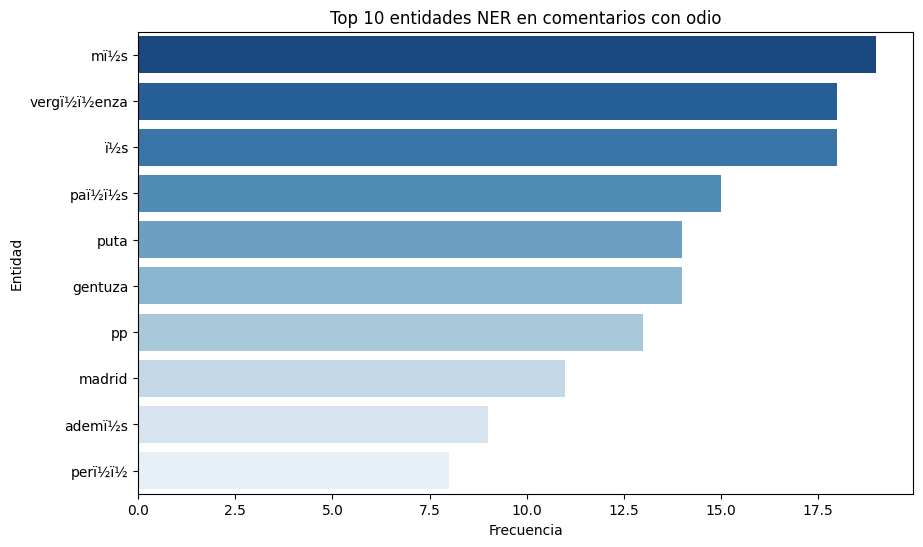

/var/folders/hk/hc_3jxjx6l3_q31yrc71m_sw0000gn/T/ipykernel_69650/791488907.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ner, x="COUNT", y="ADJ", palette="Blues_r")


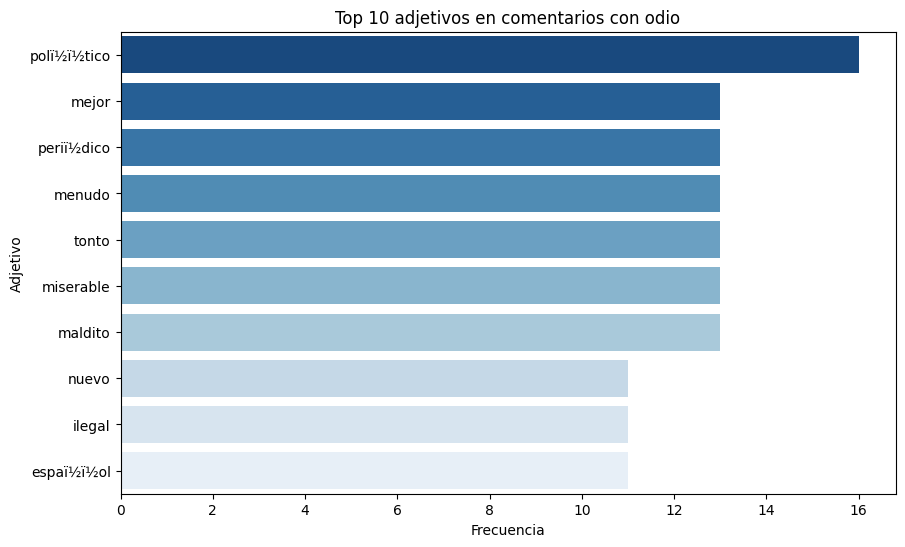

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

top_ner = pd.DataFrame(hate_words[:10], columns=["NER", "COUNT"])
plt.figure(figsize=(10,6))
sns.barplot(data=top_ner, x="COUNT", y="NER", palette="Blues_r")
plt.title("Top 10 entidades NER en comentarios con odio")
plt.xlabel("Frecuencia")
plt.ylabel("Entidad")
plt.show()

top_ner = pd.DataFrame(adj_hate_words[:10], columns=["ADJ", "COUNT"])
plt.figure(figsize=(10,6))
sns.barplot(data=top_ner, x="COUNT", y="ADJ", palette="Blues_r")
plt.title("Top 10 adjetivos en comentarios con odio")
plt.xlabel("Frecuencia")
plt.ylabel("Adjetivo")
plt.show()



<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>
 

<span>
Algunas de las caracteristicas que se han extraido y comparadas entre comentarios con odio y sin odio son:
<ul>
<li>número de palabras por comentario</li>
<li>promedio de oraciones por comentario</li>
<li>porcentaje de comentarios que contienen entidades NER</li>
<li>longitud en caracteres por comentario</li>
</ul>

<span>
Según el analisis realizado con el corpus entregado, los valores de estas caracteristicas no son representativas y no muestra diferencias claras entre comentarios con odio y sin odio. Los distribuciones son muy similares, por lo que resulta poco útil utilizarlas como caracteristicas predictivas.
</span>
<span>
Por otro lado, hay dos variables que si pueden ser de utilidad para trabajos futuros. Ambas permiten identificar aplicaciones concretas como las entidades NER y los adjetivos más repetidos entre los comentarios con odio. Como se puede observar en el grafico anterior estos podrian incorporarse en un dashboard que mida en tiempo real la frecuencia de estas palabras y detecte la aparición de nuevas.
</span>

<ul>Top 10 entidades NER en comentarios con odio</ul>
Una posible aplicación podria ser vincular estas entidades NER con los temas o contenidos generen más reacciones negativos. Esto permitiria la posibilidad de ajustar el tipo de publicaciones que se realizan y reducir la aparición de comentarios con odio.


<ul>Top 10 adjetivos en comentarios con odio</ul>
Otra posible aplicación podria ser generar un diccionario con los adjetivos ofensivos más utilizadas para así bloquearlos en los comentarios. Aunque estos diccionarios pueden se pueden burlados mediante sustitución de caracteres por números o simbolos, podrian ser un buen buen punto de partida para mitigar la publicación de comentarios con odio.

</span>